<a href="https://colab.research.google.com/github/JanPelisek/dostupnost-JMK/blob/main/travel_times.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Manažerské shrnutí**

- doplnit texty

**Příprava prostředí**

In [5]:
import subprocess
import re


# Kontrola verze JDK. Balíček r5py vyžaduje novější verzi JAVA, proto může být nutný update.
def ensure_jdk(min_major=21):
    """
    Zkontroluje, jestli je nainstalovaná Java ≥ min_major.
    Pokud ne, stáhne a nainstaluje Temurin JDK min_major.
    """
    # 1) Verze (stávající) Javy
    try:
        out = subprocess.check_output(['java', '-version'], stderr=subprocess.STDOUT)
        txt = out.decode()
        m = re.search(r'version "(?P<ver>\d+)', txt)
        current = int(m.group('ver')) if m else 0
    except Exception:
        current = 0

    # 2) Porovnánís požadovanou verzí
    if current < min_major:
        print(f"Detekována Java {current}, potřebuji alespoň {min_major}. Instaluji JDK {min_major}…")
        cmds = [
            "apt-get update -qq",
            "apt-get install -y wget tar",
            f"wget -q https://github.com/adoptium/temurin{min_major}-binaries/releases/download/jdk-{min_major}+35/"
            f"OpenJDK{min_major}U-jdk_x64_linux_hotspot_{min_major}_35.tar.gz -O openjdk{min_major}.tar.gz",
            f"mkdir -p /usr/lib/jvm/java-{min_major}",
            f"tar -xzf openjdk{min_major}.tar.gz -C /usr/lib/jvm/java-{min_major} --strip-components=1",
            f"update-alternatives --install /usr/bin/java java /usr/lib/jvm/java-{min_major}/bin/java 1",
            f"update-alternatives --install /usr/bin/javac javac /usr/lib/jvm/java-{min_major}/bin/javac 1",
            f"update-alternatives --set java /usr/lib/jvm/java-{min_major}/bin/java",
            f"update-alternatives --set javac /usr/lib/jvm/java-{min_major}/bin/javac"
        ]
        for cmd in cmds:
            print(f">>> {cmd}")
            subprocess.run(cmd, shell=True, check=True)
        # ověření
        print(subprocess.check_output(['java', '-version'], stderr=subprocess.STDOUT).decode())
    else:
        print(f"Java je ve verzi {current}, což vyhovuje (≥ {min_major}).")

ensure_jdk(21)

Java je ve verzi 21, což vyhovuje (≥ 21).


In [6]:
# Kontrola požadovaných balíčků a jejich případná instalace pokud nejsou nalezeny
import importlib.util
import sys

packages = ['osmnx', 'r5py', 'geopandas', 'matplotlib', 'pandas', 'shapely',
            'folium', 'osm2geojson', 'mapclassify', "contextily"]

def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

for package in packages:
    if importlib.util.find_spec(package) is None:
        print(f"Balíček {package} nebyl nalezen. Instaluji...")
        install_package(package)
    else:
        print(f"Balíček {package} je již nainstalován.")

Balíček osmnx je již nainstalován.
Balíček r5py je již nainstalován.
Balíček geopandas je již nainstalován.
Balíček matplotlib je již nainstalován.
Balíček pandas je již nainstalován.
Balíček shapely je již nainstalován.
Balíček folium je již nainstalován.
Balíček osm2geojson je již nainstalován.
Balíček mapclassify je již nainstalován.
Balíček contextily je již nainstalován.


In [7]:
# import knihoven
import geopandas as gpd # práce s geospatial daty
import matplotlib.pyplot as plt # vizualizace
import osmnx as ox # práce s  Openstreetmap daty
import osm2geojson # práce s Openstreetmap daty
import pandas as pd # data manipulation a analýza
import r5py # routing engine - časy a trasy
from shapely.geometry import Polygon, shape, Point # práce s polygony
import folium # interaktivní mapy
import contextily as ctx # basemaps
import requests # interakce s webovými službami a API
# Možnost pracovat v R.
%load_ext rpy2.ipython

**Geografické vymezení úlohy**



Načtení hranic Jihomoravského kraje a jednotlivých okresů

*   Položka seznamu
*   Položka seznamu




In [8]:
# API pro ADM2 v ČR (okresy).
api_url_okr = "https://www.geoboundaries.org/api/current/gbOpen/CZE/ADM2"
hranice_okr = requests.get(api_url_okr)
len(hranice_okr.json())

# Všechny okresy ČR, kontrola názvů
okresy = gpd.read_file(hranice_okr.json()['gjDownloadURL'])
display(okresy.head())
print(okresy["shapeName"].unique())

,shapeName,shapeISO,shapeID,shapeGroup,shapeType,geometry
0,Nový Jičín,,57006924B81305487356227,CZE,ADM2,"POLYGON ((18.04966 49.80866, 18.04867 49.80073..."
1,Cheb,,57006924B74936445485800,CZE,ADM2,"POLYGON ((12.38127 50.28779, 12.37307 50.28735..."
2,Sokolov,,57006924B20358302460191,CZE,ADM2,"POLYGON ((12.82103 50.04788, 12.82059 50.05541..."
3,Karlovy Vary,,57006924B50757157558324,CZE,ADM2,"POLYGON ((12.9561 49.9789, 12.95588 49.98081, ..."
4,Chomutov,,57006924B32669310027153,CZE,ADM2,"POLYGON ((13.25622 50.23573, 13.25958 50.23615..."


['Nový Jičín' 'Cheb' 'Sokolov' 'Karlovy Vary' 'Chomutov' 'Most' 'Teplice'
 'Ústí nad Labem' 'Děčín' 'Louny' 'Litoměřice' 'Česká Lípa' 'Liberec'
 'Jablonec nad Nisou' 'Semily' 'Trutnov' 'Náchod' 'Tachov' 'Domažlice'
 'Plzeň-North' 'Rakovnik' 'Klatovy' 'Plzeň-South' 'Plzeň-City' 'Rokycany'
 'Kladno' 'Mělník' 'Mladá Boleslav' 'Jičín' 'Hradec Králové'
 'Rychnov nad Kněžnou' 'Pardubice' 'Chrudim' 'Ústí nad Orlicí' 'Jeseník'
 'Nymburk' 'Kolín' 'Beroun' 'Prague-East' 'Prague' 'Prague-West' 'Benešov'
 'Příbram' 'Kutná Hora' 'České Budějovice' 'Písek' 'Prachatice'
 'Strakonice' 'Český Krumlov' 'Jindřichův Hradec' 'Tábor' 'Třebíč'
 'Pelhřimov' 'Havlíčkův Brod' 'Žďár nad Sázavou' 'Jihlava' 'Vsetín'
 'Uherské Hradiště' 'Kroměříž' 'Zlín' 'Brno-Country' 'Svitavy' 'Hodonín'
 'Znojmo' 'Břeclav' 'Blansko' 'Vyškov' 'Brno-City' 'Prostějov' 'Přerov'
 'Olomouc' 'Bruntál' 'Šumperk' 'Opava' 'Karviná' 'Frýdek-Místek'
 'Ostrava-City']


In [9]:
jhm_okresy = ['Hodonín','Brno-Country','Znojmo', 'Břeclav', 'Blansko',
              'Vyškov', 'Brno-City']

jhm_okresy_gdf = okresy[okresy["shapeName"].isin(jhm_okresy)]
print(len(jhm_okresy_gdf)) # 7 okresů
print(jhm_okresy_gdf.crs)

7
EPSG:4326


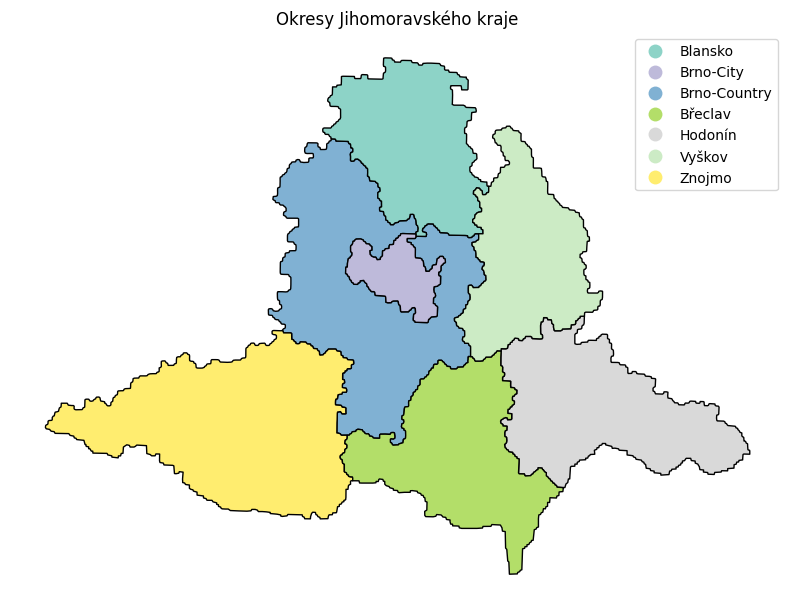

In [10]:
fig, ax = plt.subplots(figsize=(10,10))
jhm_okresy_gdf.plot(ax=ax, column="shapeName", cmap="Set3", legend=True, edgecolor='black')
ax.set_title("Okresy Jihomoravského kraje")
ax.set_axis_off()
plt.show()

In [11]:
# API pro ADM1 v ČR (kraj).
api_url_kraj = "https://www.geoboundaries.org/api/current/gbOpen/CZE/ADM1"
hranice_kraj = requests.get(api_url_kraj)
len(hranice_kraj.json())

# Všechny okresy ČR, kontrola názvů
kraje = gpd.read_file(hranice_kraj.json()['gjDownloadURL'])
display(kraje.head())
print(kraje["shapeName"].unique())

jmk = kraje[kraje["shapeName"] == "Jihomoravský kraj"]
print(jmk)

,shapeName,shapeISO,shapeID,shapeGroup,shapeType,geometry
0,Hlavní město Praha,CZ-10,73172107B16313596965023,CZE,ADM1,"POLYGON ((14.30231 50.12981, 14.30216 50.12958..."
1,Středočeský kraj,CZ-20,73172107B58641114734330,CZE,ADM1,"POLYGON ((15.4971 49.86111, 15.4971 49.86117, ..."
2,Jihočeský kraj,CZ-31,73172107B46425968394697,CZE,ADM1,"POLYGON ((13.76572 49.51394, 13.76493 49.51405..."
3,Plzeňský kraj,CZ-32,73172107B93878397098511,CZE,ADM1,"POLYGON ((13.40676 50.08958, 13.40637 50.08974..."
4,Karlovarský kraj,CZ-41,73172107B80386947470046,CZE,ADM1,"POLYGON ((13.30175 50.09935, 13.30129 50.09994..."


['Hlavní město Praha' 'Středočeský kraj' 'Jihočeský kraj' 'Plzeňský kraj'
 'Karlovarský kraj' 'Ústecký kraj' 'Liberecký kraj' 'Královéhradecký kraj'
 'Pardubický kraj' 'Kraj Vysočina' 'Jihomoravský kraj' 'Olomoucký kraj'
 'Moravskoslezský kraj' 'Zlínský kraj']
            shapeName shapeISO                  shapeID shapeGroup shapeType  \
10  Jihomoravský kraj    CZ-64  73172107B81289681513643        CZE      ADM1   

                                             geometry  
10  POLYGON ((15.54243 48.90774, 15.54349 48.90751...  


In [1]:
# GitHub LFS instalace
!apt-get update -qq
!apt-get install -qq git-lfs
!git lfs install --system

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Git LFS initialized.


In [2]:
# Kopie repozitáře na Gogle Disk do /content
!git clone https://github.com/ZP008/Data_DAMI.git

Cloning into 'Data_DAMI'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 12 (delta 2), reused 3 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (12/12), 539.68 KiB | 6.50 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [3]:
# git pull request ze zkopírovaného adresáře
%cd Data_DAMI
!git lfs pull

/content/Data_DAMI


In [12]:
# --- Příprava pro počáteční body ----

# 1) Načtení ZSJ shapefile - uložen na vašem Google Disku v /content/Data_DAMI
gdf_zsj = gpd.read_file('/content/Data_DAMI/SPH_ZSJ.shp')
gdf_zsj.head()
if gdf_zsj.crs is None:
  gdf_zsj.crs = 'epsg:5514'

gdf_zsj.to_crs(epsg=4326, inplace=True)

gdf_zsj_jmk = gdf_zsj[gdf_zsj.geometry.within(jmk.unary_union)]
print(len(gdf_zsj_jmk))
gdf_zsj_jmk.head()

<ipython-input-12-5c71d4c27f4b>:11: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  gdf_zsj_jmk = gdf_zsj[gdf_zsj.geometry.within(jmk.unary_union)]


1418


,ID,KOD_ZSJ,GEO,KOD_LAU2,KOD_KATUZE,geometry
14,43.0,43,Adamov-střed,581291.0,600041.0,"POLYGON ((16.65688 49.30468, 16.6568 49.30467,..."
51,698.0,698,Babice nad Svitavou,582794.0,600695.0,"POLYGON ((16.66729 49.28492, 16.66734 49.28499..."
52,701.0,701,Babice u Rosic,582808.0,600709.0,"POLYGON ((16.35721 49.18445, 16.35721 49.18445..."
80,400.0,400,Archlebov,586030.0,600407.0,"POLYGON ((16.98738 49.02232, 16.98737 49.02234..."
91,331945.0,331945,Vinice,582786.0,611115.0,"POLYGON ((16.66146 49.21076, 16.66153 49.2108,..."


Filtr Brno-střed, počet záznamů: 1
       kod       nazev             datum_exportu  ObjectId   Shape__Area  \
15  550973  Brno-střed 2024-09-14 00:00:00+00:00        16  3.425288e+07   

    Shape__Length                                           geometry  
15   32238.997112  POLYGON ((16.59367 49.21105, 16.59369 49.21099...  


<ipython-input-15-7982725abc5a>:24: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
<ipython-input-15-7982725abc5a>:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


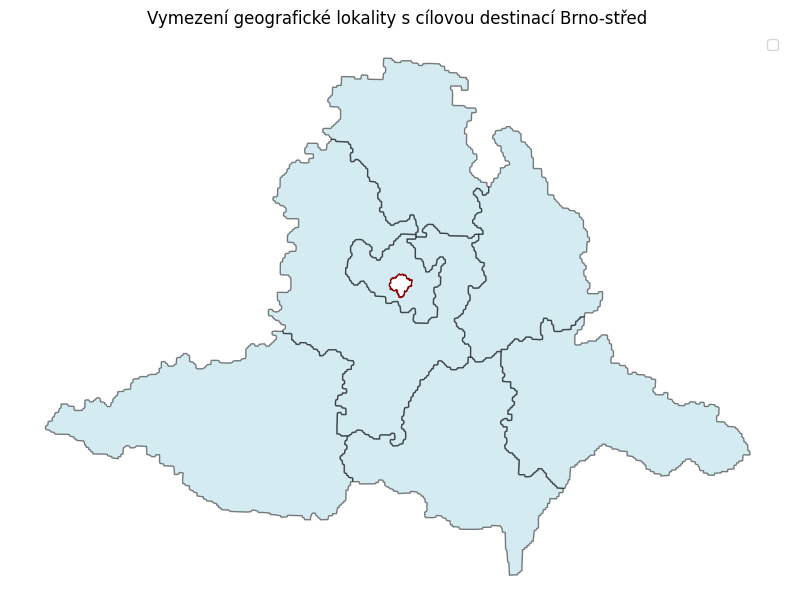

In [15]:
mestske_casti = gpd.read_file(
    "https://raw.githubusercontent.com/JanPelisek/dostupnost-JMK/main/Data_sources/m_casti_brno.geojson"
    )

# 3) Filtrace pro Brno-střed
brno_stred = mestske_casti[mestske_casti["nazev"] == "Brno-střed"]

print("Filtr Brno-střed, počet záznamů:", len(brno_stred))
print(brno_stred.head())

# 4) Kontrola a případná transformace do stejného CRS jako 'jhm_okresy_gdf'
#    Pokud jhm_okresy_gdf má jiný CRS, např. EPSG:5514 a brno_stred EPSG:4326, je třeba sjednotit.
if brno_stred.crs != jhm_okresy_gdf.crs:
    brno_stred = brno_stred.to_crs(jhm_okresy_gdf.crs)

# 5) Vykreslení - okresy a do nich polygon Brno-střed
fig, ax = plt.subplots(figsize=(10, 8))
jhm_okresy_gdf.plot(ax=ax, color="lightblue", edgecolor="black", alpha=0.5,
                    label="Okresy Jihomoravského kraje")
brno_stred.plot(ax=ax, color="white", edgecolor="darkred",
                alpha=1, label="Brno-střed")
ax.set_title("Vymezení geografické lokality s cílovou destinací Brno-střed")
ax.set_axis_off()
plt.legend()
plt.show()

CRS zastávek MHD: EPSG:4326
CRS Jihomoravského kraje: EPSG:4326


<ipython-input-16-c24bfddb6d90>:57: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


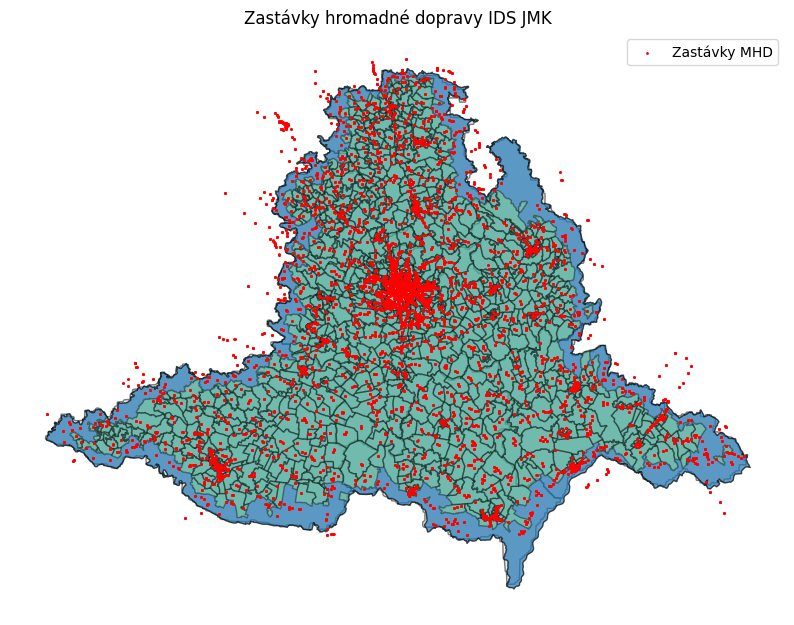

In [16]:
# Načtení zastávek
zastavky_mhd = gpd.read_file(
    "https://raw.githubusercontent.com/JanPelisek/dostupnost-JMK/main/Data_sources/stops_3349896397534691836.geojson"
    )

# Kontrolní výpis CRS systému
print("CRS zastávek MHD:", zastavky_mhd.crs)
print("CRS Jihomoravského kraje:", jhm_okresy_gdf.crs)

# Graf
fig, ax = plt.subplots(figsize=(10, 8))

# Okresy
jhm_okresy_gdf.plot(
    ax=ax,
    color="lightgrey",
    edgecolor="k",
    alpha=0.5,
    label="Okresy Jihomoravského kraje"
)

# Hranice JMK
jmk.plot(
    ax=ax,
    edgecolor="black",
    alpha=0.7,
    label="Jihomoravský kraj"
)

gdf_zsj_jmk.plot(
    ax=ax,
    color="lightgreen",
    edgecolor = "black",
    alpha=0.4,
    label="ZSJ"
)
# Brno-střed
brno_stred.plot(
    ax=ax,
    color="white",
    edgecolor="darkred",
    alpha=0.7,
    label="Brno-střed"
)

# Zastávky MHD
zastavky_mhd.plot(
    ax=ax,
    marker="o",
    color="red",
    markersize=1,
    label="Zastávky MHD"
)

ax.set_title("Zastávky hromadné dopravy IDS JMK")
ax.set_axis_off()
plt.legend()
plt.show()

In [18]:
# --- FILTRACE ZASTÁVEK UVNITŘ JMK ---

# 1) Jsou CRS zastávek i polygonu kraje jsou stejné?
zastavky_mhd = zastavky_mhd.to_crs(jmk.crs)

# 2) Sjednotíme polygon JMK do jednoho MultiPolygonu
jmk_union = jmk.unary_union

# 3) Zastávky uvnitř kraje
zastavky_jmk = zastavky_mhd[zastavky_mhd.geometry.within(jmk_union)]

# 4) Zastávky mimo kraj
zastavky_mimo_jmk = zastavky_mhd[~zastavky_mhd.index.isin(zastavky_jmk.index)]

# 5) Rychlý přehled
print(f"Zastávek celkem: {len(zastavky_mhd)}")
print(f"– v kraji: {len(zastavky_jmk)}")
print(f"– mimo kraj: {len(zastavky_mimo_jmk)}")

# 6) Tabulka zastávek mimo JMK
zastavky_mimo_jmk.head()

<ipython-input-18-2a5ddcc9bd6c>:7: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  jmk_union = jmk.unary_union


Zastávek celkem: 10817
– v kraji: 10164
– mimo kraj: 653


,stop_id,stop_name,latitude,longitude,zone_id,location_type,parent_station,wheelchair_boarding,platform_code,ObjectId,GlobalID,geometry
265,U15829Z1,"Laa an der Thaya, Stadtplatz",48.720393,16.384622,580.0,0,U15829N35,2\,NaN,266,d8522f2c-876e-4a6e-ae88-30e3643be2e8,POINT (16.38462 48.72039)
268,U15838Z1,"Laa an der Thaya, Bahnhof",48.722881,16.402679,580.0,0,U15838N36,2\,NaN,269,c6bd5ac8-7897-453c-b2a8-c8583de9dc18,POINT (16.40268 48.72288)
271,U15839Z1,"Laa an der Thaya, Therme",48.723047,16.395582,580.0,0,U15839N37,2\,NaN,272,ac2b0632-bab9-44c6-9d4e-234f6d425a3d,POINT (16.39558 48.72305)
274,U15839Z2,"Laa an der Thaya, Therme",48.723047,16.395582,580.0,0,U15839N37,2\,NaN,275,f9765e02-a164-4d2a-840c-5730b972969b,POINT (16.39558 48.72305)
277,U15838Z2,"Laa an der Thaya, Bahnhof",48.723331,16.402208,580.0,0,U15838N36,2\,NaN,278,eb5eb35c-0b21-451f-a81d-098968496be3,POINT (16.40221 48.72333)


In [19]:
# --- FILTRACE STARTOVACÍCH ZASTÁVEK MIMO OKRES BRNO-MĚSTO ---

# 1)
# Vybereme polygon okresu Brno‑město
brno_mesto_poly = (
    jhm_okresy_gdf
    .loc[jhm_okresy_gdf['shapeName'] == 'Brno-City', 'geometry']
    .unary_union
)

# 2) Filtr: zastávky v JMK, které nejsou uvnitř Brno‑město
start_zastavky = zastavky_jmk[~zastavky_jmk.geometry.within(brno_mesto_poly)]

# 3) Kontrola výsledku
print(f"Celkem zastávek v JMK: {len(zastavky_jmk)}")
print(f"Startovacích zastávek mimo Brno‑město: {len(start_zastavky)}")

# 4) Náhled
start_zastavky.head()


Celkem zastávek v JMK: 10164
Startovacích zastávek mimo Brno‑město: 8232


<ipython-input-19-986093eaddd5>:8: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  .unary_union


,stop_id,stop_name,latitude,longitude,zone_id,location_type,parent_station,wheelchair_boarding,platform_code,ObjectId,GlobalID,geometry
2,U19012Z1,"Hodonín, STS",48.870733,17.116435,900.0,0,U19012N147,2\,NaN,3,8e763c9c-41a7-406b-b129-1f9ce1bbf764,POINT (17.11644 48.87073)
5,U19002Z1,"Hodonín, Brněnská",48.862476,17.118758,900.0,0,U19002N146,2\,NaN,6,c3a4f5c0-26d6-4661-90e7-daa437f04cd5,POINT (17.11876 48.86248)
7,U15775Z2,"Hevlín, škola",48.751285,16.380187,570.0,0,U15775N4,2\,NaN,8,9fd43094-867d-487f-8b9a-21b37775b978,POINT (16.38019 48.75128)
9,U16348Z1,"Klobouky u Brna, samoobsluha",48.995079,16.867518,640.0,0,U16348N160,2\,NaN,10,809a9be4-3411-4a2f-9dda-085e2cebd7f0,POINT (16.86752 48.99508)
10,U15773Z2,"Hevlín, cihelna",48.761387,16.383460,570.0,0,U15773N5,2\,NaN,11,e6cabbf5-a676-4d14-afbd-8d0c7482d76d,POINT (16.38346 48.76139)


In [20]:
# Startovací polygony ZSJ
# Odmazání polygonu Brno-město
start_zsj = gdf_zsj_jmk[~gdf_zsj_jmk.geometry.within(brno_mesto_poly)]
start_zsj = start_zsj.rename(columns={'ID':'id'})
start_zsj['id'] = start_zsj['id'].astype(int)

print(len(start_zsj))
start_zsj.head()

1174


,id,KOD_ZSJ,GEO,KOD_LAU2,KOD_KATUZE,geometry
14,43,43,Adamov-střed,581291.0,600041.0,"POLYGON ((16.65688 49.30468, 16.6568 49.30467,..."
51,698,698,Babice nad Svitavou,582794.0,600695.0,"POLYGON ((16.66729 49.28492, 16.66734 49.28499..."
52,701,701,Babice u Rosic,582808.0,600709.0,"POLYGON ((16.35721 49.18445, 16.35721 49.18445..."
80,400,400,Archlebov,586030.0,600407.0,"POLYGON ((16.98738 49.02232, 16.98737 49.02234..."
91,331945,331945,Vinice,582786.0,611115.0,"POLYGON ((16.66146 49.21076, 16.66153 49.2108,..."


<ipython-input-21-fe8a4d94fcab>:48: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


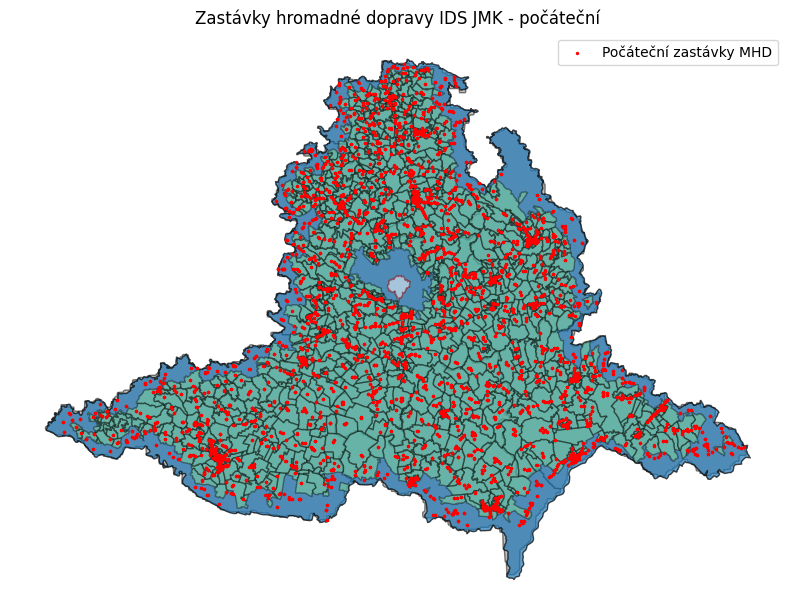

In [21]:
fig, ax = plt.subplots(figsize=(10, 8))

# Okresy
jhm_okresy_gdf.plot(
    ax = ax,
    color = "grey",
    edgecolor = "black",
    alpha = 0.5,
    label = "Okresy Jihomoravského kraje"
)

# Hranice JMK
jmk.plot(
    ax = ax,
    edgecolor = "black",
    alpha = 0.7,
    label="Jihomoravský kraj"
)

# Brno-střed
brno_stred.plot(
    ax = ax,
    color = "white",
    edgecolor = "darkred",
    alpha = 0.5,
    label = "Brno-střed"
)

start_zsj.plot(
    ax=ax,
    color = "lightgreen",
    edgecolor = "black",
    alpha=0.4,
    label = "ZSJ"
)

# Počáteční zastávky MHD
start_zastavky.plot(
    ax = ax,
    marker = "o",
    color = "red",
    markersize = 2,
    label = "Počáteční zastávky MHD"
)

ax.set_title("Zastávky hromadné dopravy IDS JMK - počáteční")
ax.set_axis_off()
plt.legend()
plt.show()

In [22]:
# --- FILTRACE CÍLOVÝCH ZASTÁVEK V OKRUHU BRNO-STŘED ---
#
# polygon Brno-střed
target_area = brno_stred.unary_union

# Filtrace: zastávky, které leží uvnitř
target_zastavky = zastavky_jmk[zastavky_jmk.geometry.within(target_area)]

# Kontrola výsledků
print(f"Cílových zastávek v Brno-střed: {len(target_zastavky)}")
target_zastavky.head()

Cílových zastávek v Brno-střed: 342


<ipython-input-22-89554e1464c8>:4: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  target_area = brno_stred.unary_union


,stop_id,stop_name,latitude,longitude,zone_id,location_type,parent_station,wheelchair_boarding,platform_code,ObjectId,GlobalID,geometry
0,U7530Z2,Dolní nádraží,49.183292,16.615558,100.0,0,U7530N1,2\,NaN,1,3298db20-d9b0-49ac-9704-fc70e0918f17,POINT (16.61556 49.18329)
1,U1011Z2,Autobusové nádraží,49.186417,16.617622,100.0,0,U1011N2,2\,NaN,2,68f78079-ac24-41c9-9d03-912bb6bdcd1c,POINT (16.61762 49.18642)
3,U1146Z33,Hlavní nádraží,49.191850,16.613617,100.0,0,U1146N3,2\,13.0,4,514f47ce-9e97-4ac5-9b85-d3dbe56ad2d0,POINT (16.61362 49.19185)
4,U1146Z31,Hlavní nádraží,49.191815,16.613991,100.0,0,U1146N3,2\,10.0,5,d42fd377-8ff2-416d-8e7a-9380359f0b36,POINT (16.61399 49.19182)
6,U7530Z1,Dolní nádraží,49.183149,16.615201,100.0,0,U7530N1,2\,NaN,7,c3c24fc4-e19b-4c63-9277-177e54b67548,POINT (16.6152 49.18315)


<ipython-input-23-803964008265>:31: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


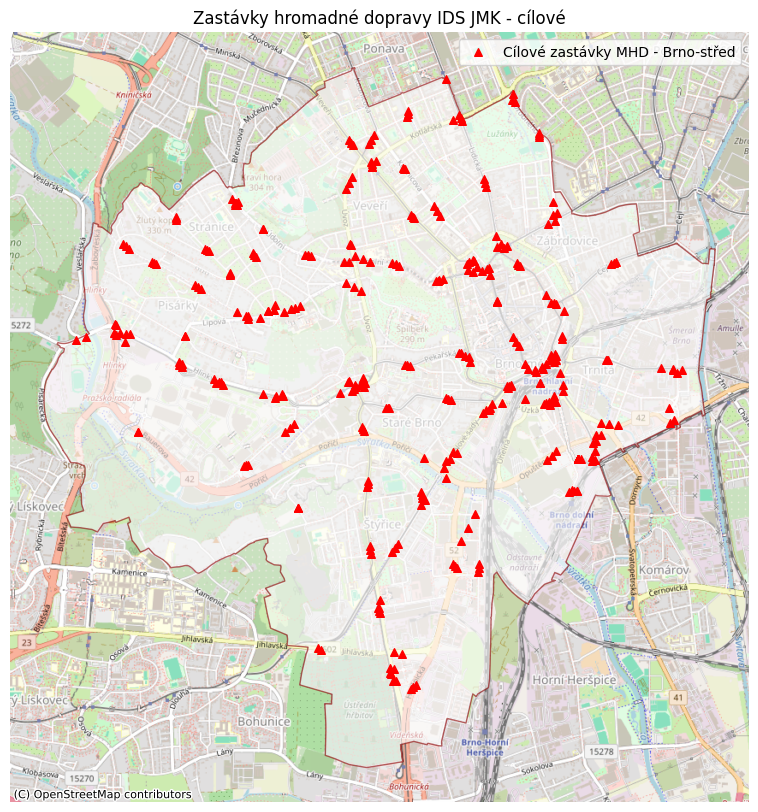

In [23]:
# Převod na Web Mercator
brno_wm = brno_stred.to_crs(epsg=3857)
target_wm = target_zastavky.to_crs(epsg=3857)

# Vykreslení
fig, ax = plt.subplots(figsize=(12, 10))
brno_wm.plot(
    ax=ax,
    color='white',
    edgecolor='darkred',
    alpha=0.6,
    label='Brno-střed'
)
target_wm.plot(
    ax=ax,
    marker='^',
    color='red',
    markersize=30,
    label='Cílové zastávky MHD - Brno-střed'
)

# Přidání basemap (např. OSM Mapnik)
ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik,
    crs=target_wm.crs.to_string()
)

ax.set_title('Zastávky hromadné dopravy IDS JMK - cílové')
ax.set_axis_off()
ax.legend()
plt.show()

**Výpočet tras**

In [24]:
## stažení GTFS dat - soubor se uloží lokálně v /content na vašem disku Google
# GTFS pro 1. polovinu 2024. z učebních materiálů. S nejnovější verzí nefungovaly výpočty.
!wget -O improved-gtfs-ids-jmk.zip "https://raw.githubusercontent.com/JanPelisek/dostupnost-JMK/main/Data_sources/improved-gtfs-ids-jmk.zip"

OpenJDK VM warning: the use of signal() and sigset() for signal chaining was deprecated in version 16.0 and will be removed in a future release. Use sigaction() instead.
--2025-04-21 09:59:37--  https://raw.githubusercontent.com/JanPelisek/dostupnost-JMK/main/Data_sources/improved-gtfs-ids-jmk.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5732295 (5.5M) [application/zip]
Saving to: ‘improved-gtfs-ids-jmk.zip’

improved-gtfs-ids-j 100%[===================>]   5.47M  --.-KB/s    in 0.09s   

2025-04-21 09:59:38 (60.2 MB/s) - ‘improved-gtfs-ids-jmk.zip’ saved [5732295/5732295]



In [25]:
# stažení OSM.PBF - soubor se uloží lokálně v /content na vašem disku Google
# Nezbytné pro vytvoření dopvní sítě
!wget -O czech_republic.osm.pbf "https://download.geofabrik.de/europe/czech-republic-latest.osm.pbf"

OpenJDK VM warning: the use of signal() and sigset() for signal chaining was deprecated in version 16.0 and will be removed in a future release. Use sigaction() instead.
--2025-04-21 09:59:40--  https://download.geofabrik.de/europe/czech-republic-latest.osm.pbf
Resolving download.geofabrik.de (download.geofabrik.de)... 65.21.229.87, 95.216.245.233, 95.217.45.61, ...
Connecting to download.geofabrik.de (download.geofabrik.de)|65.21.229.87|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 886057698 (845M) [application/octet-stream]
Saving to: ‘czech_republic.osm.pbf’

czech_republic.osm. 100%[===================>] 845.01M  5.88MB/s    in 77s     

2025-04-21 10:00:57 (11.0 MB/s) - ‘czech_republic.osm.pbf’ saved [886057698/886057698]



In [28]:
# Vytvoření <transport_network> s potvrzení nebo chybovou hláškou na konci
# může běžet až 2 hodiny
try:
    transport_network = r5py.TransportNetwork(
        "/content/Data_DAMI/czech_republic.osm.pbf",  # povinný objekt, pro výpočty při jízdě autem (transpot mode CAR)
        ["/content/Data_DAMI/improved-gtfs-ids-jmk.zip"], # volitelný, umožňuje trasy MHD
        allow_errors=False
    )
    print("TransportNetwork vytvořen úspěšně:", transport_network)
except Exception as e:
    print("Chyba při vytváření TransportNetwork:", e)

TransportNetwork vytvořen úspěšně: <r5py.r5.transport_network.TransportNetwork object at 0x7cb0b50c7490>


In [29]:
# Příprava vstupních (centroidy ZSJ) a koncových bodů (Zastávky v Brno-střed) pro Travel time matrix
origins_zsj = start_zsj.copy()
origins_zsj = origins_zsj[['id','geometry']]
origins_zsj.geometry = origins_zsj.centroid
origins_zsj = origins_zsj.set_geometry('geometry')

destinations = target_zastavky.rename(columns={'stop_id':'id'})[['id','geometry']]

# 4) Náhled výsledku
print(f"Počet ZSJ jednotek v JMK: {len(origins_zsj)}")
origins_zsj.head()

Počet ZSJ jednotek v JMK: 1174


<ipython-input-29-a79a910c5a6b>:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  origins_zsj.geometry = origins_zsj.centroid


,id,geometry
14,43,POINT (16.66538 49.30272)
51,698,POINT (16.69244 49.28182)
52,701,POINT (16.353 49.17553)
80,400,POINT (16.99472 49.05651)
91,331945,POINT (16.67045 49.21166)


In [30]:
# Kontrola vstupnich a koncovych bodu
print(origins_zsj.crs, destinations.crs)
print(origins_zsj.head(), len(origins_zsj))
print(destinations.head(), len (destinations))


EPSG:4326 EPSG:4326
        id                   geometry
14      43  POINT (16.66538 49.30272)
51     698  POINT (16.69244 49.28182)
52     701    POINT (16.353 49.17553)
80     400  POINT (16.99472 49.05651)
91  331945  POINT (16.67045 49.21166) 1174
         id                   geometry
0   U7530Z2  POINT (16.61556 49.18329)
1   U1011Z2  POINT (16.61762 49.18642)
3  U1146Z33  POINT (16.61362 49.19185)
4  U1146Z31  POINT (16.61399 49.19182)
6   U7530Z1   POINT (16.6152 49.18315) 342


In [31]:
import datetime
# testovací proměnná s jedním výchozím bodem <start>
# start =  gpd.GeoDataFrame(
#    {
#        "id": ["test_station"],
#        "geometry": [Point(16.621316, 49.309809)]
#   },
#    crs="EPSG:4326",
#)

# Výpočet dojezdových časů - MHD, přístup na zastávku WALK, odjezd 6:30 + 60 min
# Výsledné časy jsou mediánem všech možných routovatelných tras ze start do cíle v minutovém intervalu
# V pracovní den
travel_time_prac_den = r5py.TravelTimeMatrix(
    transport_network,
    origins = origins_zsj,
    destinations = destinations,
    departure = datetime.datetime(2024,2,23,6,30),
    departure_time_window = datetime.timedelta(seconds = 3600),
    transport_modes = [r5py.TransportMode.TRANSIT,
                       r5py.TransportMode.WALK
                      ],
    snap_to_network = True
)

NameError: name 'travel_time' is not defined

In [36]:
print(f"Počet záznamů: {len(travel_time_prac_den)}")
travel_time_prac_den.head()

Počet záznamů: 401508


,from_id,to_id,travel_time
0,43,U7530Z2,72.0
1,43,U1011Z2,66.0
2,43,U1146Z33,60.0
3,43,U1146Z31,60.0
4,43,U7530Z1,73.0


In [75]:
cestovni_casy_prac_den = start_zsj.merge(travel_time_prac_den, left_on='id', right_on = "from_id")

cestovni_casy_prac_den["travel_time"].describe().round()

,travel_time
count,247417.0
mean,87.0
std,21.0
min,16.0
25%,71.0
50%,90.0
75%,106.0
max,119.0


In [76]:
cestovni_casy_prac_den = cestovni_casy_prac_den.merge(
    target_zastavky[['stop_id', 'stop_name']],
    left_on='to_id', right_on='stop_id', how='left')
display(cestovni_casy_prac_den)

,id,KOD_ZSJ,GEO,KOD_LAU2,KOD_KATUZE,geometry,from_id,to_id,travel_time,stop_id,stop_name
0,43,43,Adamov-střed,581291.0,600041.0,"POLYGON ((16.65688 49.30468, 16.6568 49.30467,...",43,U7530Z2,72.0,U7530Z2,Dolní nádraží
1,43,43,Adamov-střed,581291.0,600041.0,"POLYGON ((16.65688 49.30468, 16.6568 49.30467,...",43,U1011Z2,66.0,U1011Z2,Autobusové nádraží
2,43,43,Adamov-střed,581291.0,600041.0,"POLYGON ((16.65688 49.30468, 16.6568 49.30467,...",43,U1146Z33,60.0,U1146Z33,Hlavní nádraží
3,43,43,Adamov-střed,581291.0,600041.0,"POLYGON ((16.65688 49.30468, 16.6568 49.30467,...",43,U1146Z31,60.0,U1146Z31,Hlavní nádraží
4,43,43,Adamov-střed,581291.0,600041.0,"POLYGON ((16.65688 49.30468, 16.6568 49.30467,...",43,U7530Z1,73.0,U7530Z1,Dolní nádraží
...,...,...,...,...,...,...,...,...,...,...,...
401503,328685,328685,Na Hraničkách,592889.0,788571.0,"POLYGON ((16.98296 49.28063, 16.98296 49.28064...",328685,U1177N3220,90.0,U1177N3220,Schodová
401504,328685,328685,Na Hraničkách,592889.0,788571.0,"POLYGON ((16.98296 49.28063, 16.98296 49.28064...",328685,U1517N3024,104.0,U1517N3024,Preslova
401505,328685,328685,Na Hraničkách,592889.0,788571.0,"POLYGON ((16.98296 49.28063, 16.98296 49.28064...",328685,U1320N3025,94.0,U1320N3025,Květná
401506,328685,328685,Na Hraničkách,592889.0,788571.0,"POLYGON ((16.98296 49.28063, 16.98296 49.28064...",328685,U1149N3029,87.0,U1149N3029,Holandská


In [81]:
median_cesta_prac_den = cestovni_casy_prac_den.groupby("from_id").median("travel_time")
median_cesta_prac_den

,id,KOD_ZSJ,KOD_LAU2,KOD_KATUZE,travel_time
from_id,,,,,
43,43.0,43.0,581291.0,600041.0,72.0
400,400.0,400.0,586030.0,600407.0,116.0
698,698.0,698.0,582794.0,600695.0,73.0
701,701.0,701.0,582808.0,600709.0,82.0
825,825.0,825.0,581372.0,600822.0,118.0
...,...,...,...,...,...
331481,331481.0,331481.0,583057.0,645664.0,91.0
331678,331678.0,331678.0,583863.0,747840.0,82.0
331911,331911.0,331911.0,582786.0,612065.0,36.0
